# Hit Energy Distribution CONF6 mu- MC

Read all ROOT files in the CONF6 mu- MC directory and plot only the hit energy distribution.


In [1]:
from pathlib import Path
import re

import ROOT
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC')
STYLE_PATH = Path('/home/llr/ilc/shi/code/Plot_style/cepc.mplstyle')
FIG_SIZE = (6, 6)

if STYLE_PATH.exists():
    plt.style.use(str(STYLE_PATH))

for lib_name in ('libDDG4Plugins', 'libDDG4IO', 'libDDG4'):
    ROOT.gSystem.Load(lib_name)


def natural_key(path):
    return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', path.name)]


root_files = sorted(DATA_DIR.glob('*.root'), key=natural_key)
if not root_files:
    raise FileNotFoundError(f'No ROOT files found in {DATA_DIR}')

print(f'Data directory: {DATA_DIR}')
print(f'Number of ROOT files: {len(root_files)}')
print(f'First file: {root_files[0]}')
print(f'Last file : {root_files[-1]}')

Warning in <TClassTable::Add>: class _Rb_tree_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class _Rb_tree_const_iterator<pair<const int,dd4hep::sim::Geant4Particle*> > already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleRun already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::SimpleEvent already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::DataExtension already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4HitData::MonteCarloContrib already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Tracker::Hit already in TClassTable
Warning in <TClassTable::Add>: class dd4hep::sim::Geant4Calorimeter already in TClassTable
Warning in <TClassTable::A

Data directory: /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC
Number of ROOT files: 50
First file: /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC/100GeV_1.root
Last file : /home/llr/ilc/shi/data/SiWECAL-Prototype/TB2026-06/CONF6/mu-/MC/100GeV_50.root


In [2]:
cellID = []
energy = []
pos_x = []
pos_y = []
pos_z = []
contrib_begin = []
contrib_end = []

Step_CellID = []
Step_x = []
Step_y = []
Step_z = []
Step_E = []
Step_t = []
Step_length = []
Step_trackID = []
Step_pdgID = []

file_summary = []

for file_path in root_files:
    root_file = ROOT.TFile.Open(str(file_path))
    if not root_file or root_file.IsZombie():
        raise OSError(f'Cannot open ROOT file: {file_path}')

    tree = root_file.Get('EVENT')
    if not tree:
        root_file.Close()
        raise RuntimeError(f'Cannot find EVENT tree in {file_path}')

    n_events = tree.GetEntries()
    n_hits_file = 0
    n_steps_file = 0

    for ev in range(n_events):
        tree.GetEntry(ev)
        hits = tree.simplecaloRO

        event_cellID = []
        event_energy = []
        event_pos_x = []
        event_pos_y = []
        event_pos_z = []
        event_contrib_begin = []
        event_contrib_end = []

        event_step_cellID = []
        event_step_x = []
        event_step_y = []
        event_step_z = []
        event_step_E = []
        event_step_t = []
        event_step_length = []
        event_step_trackID = []
        event_step_pdgID = []

        step_offset = 0
        for i in range(hits.size()):
            hit = hits.at(i)
            event_cellID.append(int(hit.cellID))
            event_energy.append(float(hit.energyDeposit))
            event_pos_x.append(float(hit.position.x()))
            event_pos_y.append(float(hit.position.y()))
            event_pos_z.append(float(hit.position.z()))

            event_contrib_begin.append(step_offset)
            for j in range(hit.truth.size()):
                contrib = hit.truth.at(j)
                event_step_cellID.append(int(hit.cellID))
                event_step_x.append(float(contrib.x))
                event_step_y.append(float(contrib.y))
                event_step_z.append(float(contrib.z))
                event_step_E.append(float(contrib.deposit))
                event_step_t.append(float(contrib.time))
                event_step_length.append(float(contrib.length))
                event_step_trackID.append(int(contrib.trackID))
                event_step_pdgID.append(int(contrib.pdgID))
                step_offset += 1
            event_contrib_end.append(step_offset)

        cellID.append(np.array(event_cellID, dtype=np.int64))
        energy.append(np.array(event_energy, dtype=np.float64))
        pos_x.append(np.array(event_pos_x, dtype=np.float64))
        pos_y.append(np.array(event_pos_y, dtype=np.float64))
        pos_z.append(np.array(event_pos_z, dtype=np.float64))
        contrib_begin.append(np.array(event_contrib_begin, dtype=np.int64))
        contrib_end.append(np.array(event_contrib_end, dtype=np.int64))

        Step_CellID.append(np.array(event_step_cellID, dtype=np.int64))
        Step_x.append(np.array(event_step_x, dtype=np.float64))
        Step_y.append(np.array(event_step_y, dtype=np.float64))
        Step_z.append(np.array(event_step_z, dtype=np.float64))
        Step_E.append(np.array(event_step_E, dtype=np.float64))
        Step_t.append(np.array(event_step_t, dtype=np.float64))
        Step_length.append(np.array(event_step_length, dtype=np.float64))
        Step_trackID.append(np.array(event_step_trackID, dtype=np.int64))
        Step_pdgID.append(np.array(event_step_pdgID, dtype=np.int64))

        n_hits_file += len(event_energy)
        n_steps_file += len(event_step_E)

    root_file.Close()
    file_summary.append((file_path.name, n_events, n_hits_file, n_steps_file))

cellID = np.array(cellID, dtype=object)
energy = np.array(energy, dtype=object)
pos_x = np.array(pos_x, dtype=object)
pos_y = np.array(pos_y, dtype=object)
pos_z = np.array(pos_z, dtype=object)
contrib_begin = np.array(contrib_begin, dtype=object)
contrib_end = np.array(contrib_end, dtype=object)

Step_CellID = np.array(Step_CellID, dtype=object)
Step_x = np.array(Step_x, dtype=object)
Step_y = np.array(Step_y, dtype=object)
Step_z = np.array(Step_z, dtype=object)
Step_E = np.array(Step_E, dtype=object)
Step_t = np.array(Step_t, dtype=object)
Step_length = np.array(Step_length, dtype=object)
Step_trackID = np.array(Step_trackID, dtype=object)
Step_pdgID = np.array(Step_pdgID, dtype=object)

all_energy = np.concatenate(energy)
all_energy_mev = all_energy

print(f'Total files: {len(file_summary)}')
print(f'Total events: {len(energy)}')
print(f'Total hits: {len(all_energy)}')
print(f'Total steps: {sum(item[3] for item in file_summary)}')
print('File summary preview:')
for name, n_events, n_hits, n_steps in file_summary[:5]:
    print(f'  {name}: {n_events} events, {n_hits} hits, {n_steps} steps')
if len(file_summary) > 5:
    print('  ...')


Total files: 50
Total events: 10000
Total hits: 183629
Total steps: 8111293
File summary preview:
  100GeV_1.root: 200 events, 3615 hits, 152804 steps
  100GeV_2.root: 200 events, 3819 hits, 186953 steps
  100GeV_3.root: 200 events, 3744 hits, 156983 steps
  100GeV_4.root: 200 events, 3651 hits, 167706 steps
  100GeV_5.root: 200 events, 3376 hits, 118260 steps
  ...


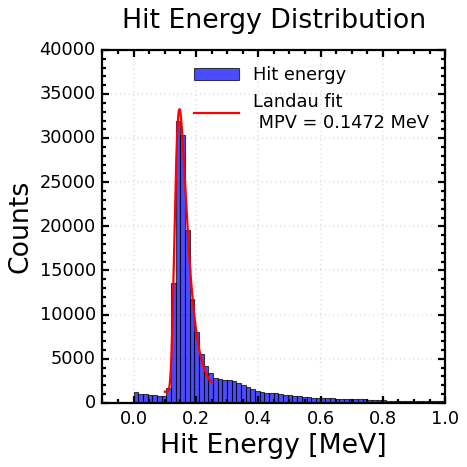

Contains zero hit energy: False
Min hit energy [MeV]: 1.47087e-07
Max hit energy [MeV]: 82.3196
Landau MPV [MeV]: 0.147157 ± 0.000421


In [18]:
from scipy.optimize import curve_fit

hist_bins = 100
hist_range = (0, 1.5)
fit_range = (0.1, 0.25)

fit_energy = all_energy[np.isfinite(all_energy)]
fit_energy = fit_energy[(fit_energy >= fit_range[0]) & (fit_energy <= fit_range[1])]
if len(fit_energy) == 0:
    raise RuntimeError(f'No hit energy entries in fit range {fit_range}')

counts, bin_edges = np.histogram(fit_energy, bins=hist_bins, range=hist_range)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

def moyal_landau(x, amplitude, mpv, sigma, offset):
    z = (x - mpv) / sigma
    return amplitude * np.exp(-0.5 * (z + np.exp(-z))) / (np.sqrt(2 * np.pi) * sigma) * bin_width + offset

nonzero = counts > 0
x_fit_data = bin_centers[nonzero]
y_fit_data = counts[nonzero]
initial_mpv = x_fit_data[np.argmax(y_fit_data)]
initial = (np.sum(counts), initial_mpv, 0.05, 0.0)
bounds = ([0.0, fit_range[0], 1e-6, 0.0], [np.inf, fit_range[1], np.inf, np.inf])
popt, pcov = curve_fit(moyal_landau, x_fit_data, y_fit_data, p0=initial, bounds=bounds, maxfev=20000)
amplitude, mpv, sigma, offset = popt
mpv_err = np.sqrt(pcov[1, 1]) if pcov.size else np.nan

x_fit = np.linspace(fit_range[0], fit_range[1], 500)
y_fit = moyal_landau(x_fit, *popt)

plt.figure(figsize=FIG_SIZE)
plt.hist(all_energy, bins=hist_bins, range=hist_range, color='blue', alpha=0.7, label='Hit energy')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'Landau fit\n MPV = {mpv:.4g} MeV')
plt.xlabel('Hit Energy [MeV]')
plt.xlim(-0.1, 1.)
plt.ylabel('Counts')
plt.title('Hit Energy Distribution')
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Contains zero hit energy: {np.any(all_energy == 0.0)}')
print(f'Min hit energy [MeV]: {np.min(all_energy):.6g}')
print(f'Max hit energy [MeV]: {np.max(all_energy):.6g}')
print(f'Landau MPV [MeV]: {mpv:.6g} ± {mpv_err:.3g}')

